# 04 — Selección del algoritmo (comparación interna)

**Uso interno, no es un entregable del informe P1.** El enunciado pide implementar y reportar **un** algoritmo
tabular con su ablación de exploración. La comparación entre MC, SARSA y Q-Learning es un criterio de P2.
Aquí solo se documenta por qué el baseline reportado es Q-Learning.

Condiciones idénticas para los tres: representación de estado C, ε decreciente 1.0 → 0.1, 20 000 episodios,
5 semillas y los mismos 500 inicios de evaluación greedy. Solo cambia la regla de actualización
(`src/agents.py`):
- **Q-Learning:** off-policy, $\max_a Q(s',a)$, α = 0.03.
- **SARSA:** on-policy, $Q(s',a')$ con la acción realmente elegida, α = 0.03.
- **MC first-visit on-policy**, en dos variantes: con promedio muestral (el clásico) y con α = 0.03 constante,
  igual que los TD. Sin bootstrap: un episodio truncado corta su retorno en $T_{max}$.

Regenerar: `python -m src.train --preset algorithms --out notebooks/artifacts/runs_algorithms` (≈ 2.5 min).

| algoritmo | final <40 | últimas 5 <40 | peor de últimas 5 | final ≤40 | G₀ greedy final |
|---|---|---|---|---|---|
| algo_mc_first_visit | 0.681 ± 0.073 | 0.681 ± 0.073 | 0.540 | 0.708 | 85.3 |
| algo_mc_first_visit_alpha | 0.424 ± 0.284 | 0.482 ± 0.135 | 0.032 | 0.442 | 45.0 |
| algo_qlearning | 0.738 ± 0.006 | 0.739 ± 0.007 | 0.708 | 0.763 | 91.6 |
| algo_sarsa | 0.734 ± 0.007 | 0.720 ± 0.013 | 0.570 | 0.760 | 91.2 |

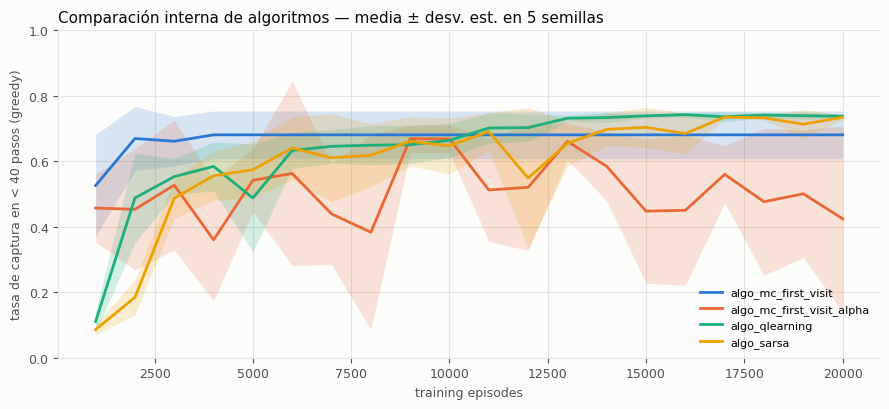

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, Markdown
os.chdir("/workspace") if os.path.isdir("/workspace/src") else None
from src import plots

runs = plots.load_runs("notebooks/artifacts/runs_algorithms")
lines = ["| algoritmo | final <40 | últimas 5 <40 | peor de últimas 5 | final ≤40 | G₀ greedy final |", "|---|---|---|---|---|---|"]
for name, rs in runs.items():
    final = [r["final_eval"]["capture_rate_lt40"] for r in rs]
    last5 = [np.mean([e["capture_rate_lt40"] for e in r["evals"][-5:]]) for r in rs]
    worst = min(min(e["capture_rate_lt40"] for e in r["evals"][-5:]) for r in rs)
    le40 = [r["final_eval"]["capture_rate_le40"] for r in rs]
    g0 = [r["final_eval"]["mean_return"] for r in rs]
    lines.append(f"| {name} | {np.mean(final):.3f} ± {np.std(final):.3f} | {np.mean(last5):.3f} ± {np.std(last5):.3f} | "
                 f"{worst:.3f} | {np.mean(le40):.3f} | {np.mean(g0):.1f} |")
display(Markdown("\n".join(lines)))

fig, ax = plt.subplots(figsize=(9, 4.2))
plots.plot_eval_curves(runs, "capture_rate_lt40", ax=ax, ylabel="tasa de captura en < 40 pasos (greedy)",
                       title="Comparación interna de algoritmos — media ± desv. est. en 5 semillas", direct_labels=False)
ax.set_ylim(0, 1)
fig.tight_layout(); fig.savefig("notebooks/artifacts/fig_internal_algorithms.png", dpi=200)

**Decisión:** se reporta **Q-Learning**, que tiene la mayor tasa de captura y es la más estable entre semillas y
entre evaluaciones sucesivas.

- **SARSA** llega a un nivel parecido, pero con colapsos ocasionales de la política greedy.
- **MC con promedio muestral** se **congela** temprano: la curva queda plana desde ≈ 4 000 episodios. El paso
  1/N se anula, así que los retornos recogidos al inicio con una política casi aleatoria (ε ≈ 1) conservan
  todo su peso y los valores Q dejan de seguir a la política que mejora.
- **MC con α constante** evita ese congelamiento pero es muy **inestable**. Cada retorno suma hasta 40 pasos
  ruidosos más un bono de captura de todo o nada (+100), los episodios truncados no se corrigen con bootstrap y
  los estados tienen aliasing. Las actualizaciones tienen alta varianza, y el bootstrap de los métodos TD la
  reduce.

Frase sugerida para el informe: *«También se probaron SARSA y Monte Carlo first-visit bajo condiciones idénticas;
se eligió Q-Learning por su mayor tasa de captura y su menor varianza entre semillas.»*